# Deteksi Dini Risiko Pola Makan Tidak Seimbang Melalui Analisis Visual Makanan pada Program MBG

Dataset: Roboflow `ompreng-mbg-fix` v2  
Kelas: `buah`, `karbohidrat`, `ompreng`, `protein`, `sayur`, `susu`  
Model: U-Net + MobileNetV2 backbone + Fuzzy Logic Classifier


## Instalasi & Import Library

In [1]:
# Install library eksternal
!pip install scikit-fuzzy opencv-python-headless pillow tqdm roboflow -q

import os
import json
import random
import shutil
import datetime
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
from PIL import Image, ImageDraw

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
import tensorflow.keras.backend as K

import skfuzzy as fuzz
from skfuzzy import control as ctrl

from sklearn.model_selection import train_test_split


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 111.5 MB/s eta 0:00:00


## Konfigurasi Dasar & Global Variabel

In [2]:
# Seed untuk reproduksibilitas
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Konfigurasi GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU tersedia: {len(gpus)} GPU')
else:
    print('Menggunakan CPU')


GPU tersedia: 1 GPU


## Download Dataset dari Roboflow

In [3]:
from roboflow import Roboflow

rf      = Roboflow(api_key="LAUgmCFfKK8FG1DqrJg0")
project = rf.workspace("iqbals-workspace-wjr03").project("ompreng-mbg-fix")
version = project.version(2)
dataset = version.download("tensorflow")

print("Dataset berhasil diunduh.")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Ompreng-MBG-Fix-2 in tensorflow:: 100%|██████████| 1409/1409 [00:00<00:00, 5090.71it/s]

Dataset berhasil diunduh.


## Path, Hyperparameter & Class Mapping

In [6]:
# ── Path Dataset (struktur Roboflow) ────────────────────────────────────────
BASE_DIR     = Path('Ompreng-MBG-Fix-2')

IMAGES_TRAIN = BASE_DIR / 'train'
MASKS_TRAIN  = BASE_DIR / 'train_masks'

IMAGES_VAL   = BASE_DIR / 'valid'
MASKS_VAL    = BASE_DIR / 'valid_masks'

IMAGES_TEST  = BASE_DIR / 'test'
MASKS_TEST   = BASE_DIR / 'test_masks'

METADATA_DIR = BASE_DIR / 'metadata'

MODEL_SAVE_PATH  = 'models/unet_mbg.keras'
FINAL_MODEL_PATH = 'models/unet_mbg_final.keras'
LOG_DIR          = 'logs/fit/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')

# ── Hyperparameter ───────────────────────────────────────────────────────────
IMG_HEIGHT    = 256
IMG_WIDTH     = 256
IMG_CHANNELS  = 3
BATCH_SIZE    = 8
EPOCHS        = 50
LEARNING_RATE = 1e-4

# ── Class Mapping (Dataset Asli Roboflow) ────────────────────────────────────
# Label di CSV: buah, karbohidrat, ompreng, protein, sayur, susu
# 'ompreng' = wadah/tray aluminium → tidak dihitung sebagai bahan pangan
CLASS_MAPPING = {
    0: 'background',
    1: 'buah',
    2: 'karbohidrat',
    # 3: 'ompreng',    # tray/wadah, dikeluarkan dari perhitungan nutrisi
    3: 'protein',
    4: 'sayur',
    5: 'susu'
}
NUM_CLASSES = len(CLASS_MAPPING)

# ── Warna Visualisasi per Kelas ──────────────────────────────────────────────
CLASS_COLORS = {
    0: [0,   0,   0  ],   # background  → hitam
    1: [255, 140, 0  ],   # buah        → oranye
    2: [240, 220, 80 ],   # karbohidrat → kuning
    # 3: [180, 180, 180],   # ompreng     → abu-abu metalik
    3: [200, 80,  80 ],   # protein     → merah
    4: [50,  200, 50 ],   # sayur       → hijau
    5: [100, 190, 255],   # susu        → biru muda
}

# ── Mapping Kelas → Kategori Nutrisi ─────────────────────────────────────────
# 'ompreng' sengaja tidak dimasukkan (bukan makanan)
NUTRISI_MAPPING = {
    'buah'        : 'serat',    # buah-buahan      → serat & vitamin
    'karbohidrat' : 'karbo',    # nasi/mie/roti dll → karbohidrat
    'protein'     : 'protein',  # lauk hewani/nabati→ protein
    'sayur'       : 'serat',    # sayuran           → serat
    'susu'        : 'susu',     # susu              → kategori tersendiri MBG
}

# ── Buat direktori yang dibutuhkan ───────────────────────────────────────────
for d in [METADATA_DIR, Path('models'), Path(LOG_DIR)]:
    d.mkdir(parents=True, exist_ok=True)

print(f'NUM_CLASSES  : {NUM_CLASSES}')
print(f'CLASS_MAPPING: {CLASS_MAPPING}')


NUM_CLASSES  : 6
CLASS_MAPPING: {0: 'background', 1: 'buah', 2: 'karbohidrat', 3: 'protein', 4: 'sayur', 5: 'susu'}


## Data Preparation – Generate Mask dari Anotasi Roboflow CSV

In [7]:
# Simpan class mapping ke metadata
class_mapping_str = {str(k): v for k, v in CLASS_MAPPING.items()}
metadata_file = METADATA_DIR / 'class_mapping.json'
with open(metadata_file, 'w') as f:
    json.dump(class_mapping_str, f, indent=2)

print(f'Metadata disimpan: {metadata_file}')
print(json.dumps(class_mapping_str, indent=2))


Metadata disimpan: Ompreng-MBG-Fix-2/metadata/class_mapping.json
{
  "0": "background",
  "1": "buah",
  "2": "karbohidrat",
  "3": "protein",
  "4": "sayur",
  "5": "susu"
}


In [8]:
def generate_masks_from_csv(
    base_path: Path,
    split_name: str,
    class_map: dict
) -> None:
    """
    Baca _annotations.csv di folder split, lalu buat mask .png untuk
    setiap gambar. Setiap bounding-box digambar sebagai persegi penuh
    pada mask dengan nilai piksel = class_id.

    Args:
        base_path  : Path root dataset (Ompreng-MBG-Fix-2)
        split_name : 'train' | 'valid' | 'test'
        class_map  : {class_id (int): class_name (str)}
    """
    img_dir  = base_path / split_name
    mask_dir = base_path / f"{split_name}_masks"
    csv_path = img_dir / "_annotations.csv"

    if not csv_path.exists():
        print(f"[Skip] CSV tidak ditemukan: {csv_path}")
        return

    existing = list(mask_dir.glob('*.png'))
    if existing:
        print(f"[Skip] Mask sudah ada di {mask_dir} ({len(existing)} file)")
        return

    mask_dir.mkdir(parents=True, exist_ok=True)

    # Reverse map: nama kelas (lower) → class_id
    name_to_id = {v.lower(): k for k, v in class_map.items() if k != 0}

    df      = pd.read_csv(csv_path)
    grouped = df.groupby('filename')
    print(f"Memproses {len(grouped)} gambar di split '{split_name}'...")

    for filename, group in tqdm(grouped):
        mask = np.zeros((IMG_HEIGHT, IMG_WIDTH), dtype=np.uint8)

        for _, row in group.iterrows():
            class_name = str(row['class']).strip().lower()
            class_id   = name_to_id.get(class_name, 0)
            if class_id == 0:
                continue

            # Normalisasi koordinat ke resolusi mask
            x1 = int(row['xmin'] * IMG_WIDTH  / row['width'])
            y1 = int(row['ymin'] * IMG_HEIGHT / row['height'])
            x2 = int(row['xmax'] * IMG_WIDTH  / row['width'])
            y2 = int(row['ymax'] * IMG_HEIGHT / row['height'])

            cv2.rectangle(mask, (x1, y1), (x2, y2), int(class_id), -1)

        mask_path = mask_dir / f"{Path(filename).stem}.png"
        cv2.imwrite(str(mask_path), mask)

    print(f"✓ {len(grouped)} mask tersimpan di {mask_dir}")


# Jalankan untuk ketiga split
for split in ['train', 'valid', 'test']:
    generate_masks_from_csv(BASE_DIR, split, CLASS_MAPPING)

print("\nKonversi mask dari CSV selesai.")


Memproses 1296 gambar di split 'train'...


100%|██████████| 1296/1296 [00:01<00:00, 1023.09it/s]


✓ 1296 mask tersimpan di Ompreng-MBG-Fix-2/train_masks
Memproses 54 gambar di split 'valid'...


100%|██████████| 54/54 [00:00<00:00, 1013.87it/s]


✓ 54 mask tersimpan di Ompreng-MBG-Fix-2/valid_masks
Memproses 54 gambar di split 'test'...


100%|██████████| 54/54 [00:00<00:00, 948.74it/s]

✓ 54 mask tersimpan di Ompreng-MBG-Fix-2/test_masks

Konversi mask dari CSV selesai.


Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.
Glyph 128247 (\N{CAMERA}) missing from font(s) DejaVu Sans.
Glyph 127917 (\N{PERFORMING ARTS}) missing from font(s) DejaVu Sans.
Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) DejaVu Sans.


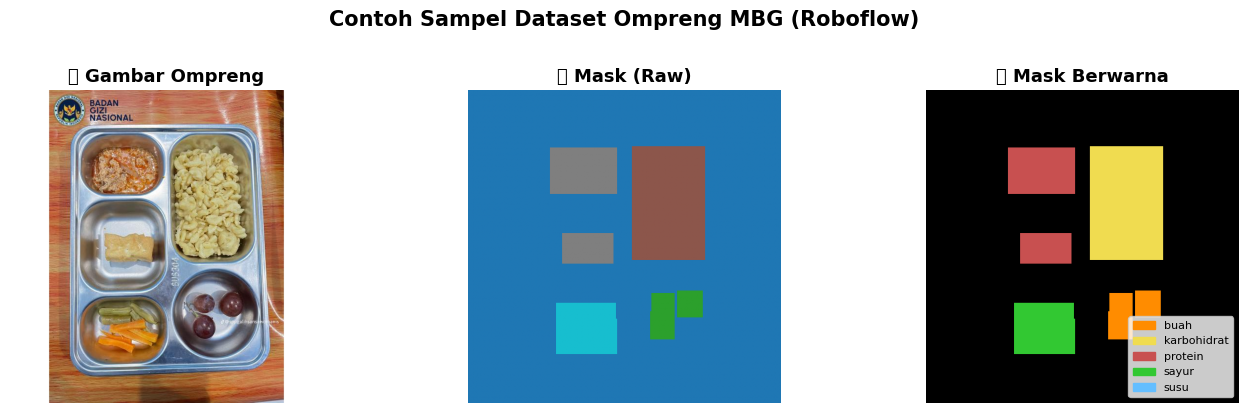

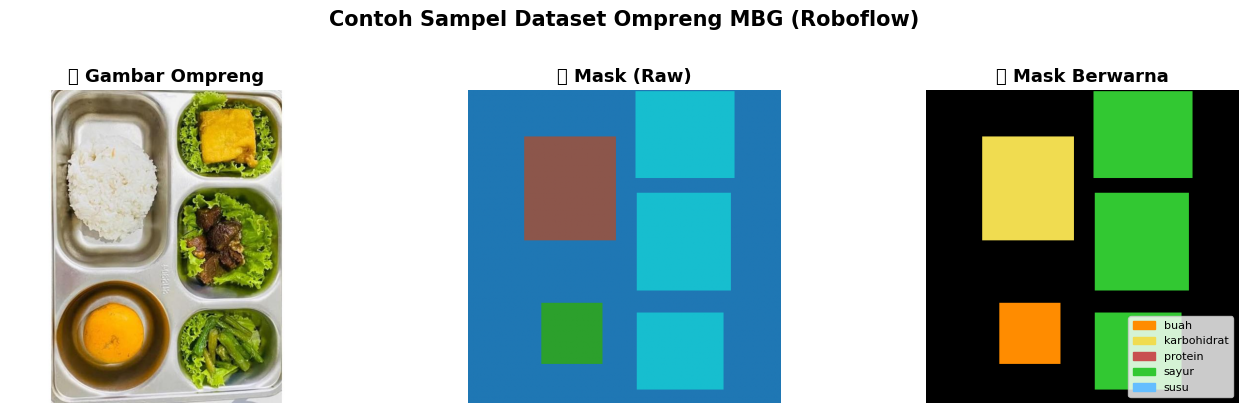

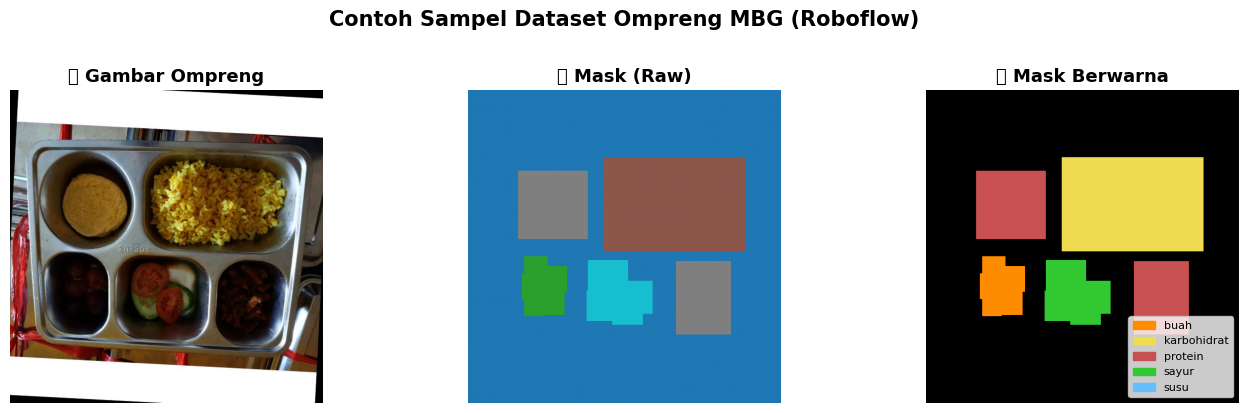

In [9]:
# Visualisasi Sampel Dataset
def visualize_sample(img_path, mask_path, class_mapping, class_colors):
    img    = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    mask   = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    colored = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cls_id, color in class_colors.items():
        colored[mask == cls_id] = color

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img);                 axes[0].set_title('📷 Gambar Ompreng',  fontsize=13, fontweight='bold')
    axes[1].imshow(mask, cmap='tab10');  axes[1].set_title('🎭 Mask (Raw)',       fontsize=13, fontweight='bold')
    axes[2].imshow(colored);            axes[2].set_title('🎨 Mask Berwarna',    fontsize=13, fontweight='bold')

    patches = [mpatches.Patch(color=np.array(c)/255, label=class_mapping[i])
               for i, c in class_colors.items() if i > 0]
    axes[2].legend(handles=patches, loc='lower right', fontsize=8)
    for ax in axes: ax.axis('off')

    plt.suptitle('Contoh Sampel Dataset Ompreng MBG (Roboflow)',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

# Tampilkan 3 sampel acak dari train split
img_paths  = sorted(IMAGES_TRAIN.glob('*.[jp][pn]g'))
mask_paths = sorted(MASKS_TRAIN.glob('*.png'))
n_sample   = min(3, len(img_paths))

for i in random.sample(range(min(len(img_paths), len(mask_paths))), n_sample):
    visualize_sample(img_paths[i], mask_paths[i], CLASS_MAPPING, CLASS_COLORS)


## Data Pipeline

In [10]:
# Load & preprocess gambar dan mask
def load_image_mask(img_path: str, mask_path: str):
    # Load gambar — support jpg & png
    raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32) / 255.0

    # Load mask
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, [IMG_HEIGHT, IMG_WIDTH],
                           method=tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)

    # Clip nilai class agar tidak melebihi NUM_CLASSES
    mask = tf.clip_by_value(mask, 0, NUM_CLASSES - 1)

    # One-hot encoding
    mask_onehot = tf.one_hot(mask, NUM_CLASSES)
    return img, mask_onehot


# Augmentasi data on-the-fly
@tf.function
def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, 0.15)
    img = tf.image.random_contrast(img, 0.85, 1.15)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


# Membuat tf.data.Dataset dari dua folder (images + masks)
def build_dataset(img_dir: Path, mask_dir: Path,
                  augment_data: bool = False,
                  batch_size: int = BATCH_SIZE) -> tf.data.Dataset:
    img_paths  = sorted(img_dir.glob('*.[jp][pn]g'))
    mask_paths = sorted(mask_dir.glob('*.png'))

    # Pastikan jumlah sama (stem yang cocok)
    img_stems  = {p.stem: p for p in img_paths}
    mask_stems = {p.stem: p for p in mask_paths}
    common     = sorted(set(img_stems) & set(mask_stems))

    matched_imgs  = [str(img_stems[s])  for s in common]
    matched_masks = [str(mask_stems[s]) for s in common]

    print(f"  {img_dir.name}: {len(common)} pasang gambar-mask")

    ds = tf.data.Dataset.from_tensor_slices((matched_imgs, matched_masks))
    ds = ds.map(load_image_mask, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


# Build dataset dari split Roboflow
print("Membangun dataset...")
train_ds = build_dataset(IMAGES_TRAIN, MASKS_TRAIN, augment_data=True)
val_ds   = build_dataset(IMAGES_VAL,   MASKS_VAL,   augment_data=False)
test_ds  = build_dataset(IMAGES_TEST,  MASKS_TEST,  augment_data=False)

print(f'\nTrain : {len(train_ds)} batch')
print(f'Val   : {len(val_ds)} batch')
print(f'Test  : {len(test_ds)} batch')

# Verifikasi shape
for x, y in train_ds.take(1):
    print(f'\nShape input : {x.shape}  (B, H, W, C)')
    print(f'Shape mask  : {y.shape}  (B, H, W, num_classes)')


Membangun dataset...
  train: 1296 pasang gambar-mask
  valid: 54 pasang gambar-mask
  test: 54 pasang gambar-mask

Train : 162 batch
Val   : 7 batch
Test  : 7 batch

Shape input : (8, 256, 256, 3)  (B, H, W, C)
Shape mask  : (8, 256, 256, 6)  (B, H, W, num_classes)


## Arsitektur Model

In [11]:
# Custom Layer: Attention Gate
class AttentionGate(layers.Layer):
    def __init__(self, filters: int, name: str = 'attention_gate', **kwargs):
        super().__init__(name=name, **kwargs)
        self.filters = filters
        self.W_g     = layers.Conv2D(filters, 1, use_bias=False, padding='same')
        self.bn_g    = layers.BatchNormalization()
        self.W_x     = layers.Conv2D(filters, 1, use_bias=False, padding='same')
        self.bn_x    = layers.BatchNormalization()
        self.psi     = layers.Conv2D(1, 1, use_bias=False, padding='same')
        self.bn_psi  = layers.BatchNormalization()

    def call(self, x, g, training=False):
        g_resized = tf.image.resize(g, tf.shape(x)[1:3], method='bilinear')
        g_proc    = self.bn_g(self.W_g(g_resized), training=training)
        x_proc    = self.bn_x(self.W_x(x),         training=training)
        combined  = tf.nn.relu(g_proc + x_proc)
        alpha     = tf.nn.sigmoid(self.bn_psi(self.psi(combined), training=training))
        return x * alpha

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'filters': self.filters})
        return cfg


# Custom Layer: ConvBnRelu
class ConvBnRelu(layers.Layer):
    def __init__(self, filters: int, kernel_size: int = 3,
                 name: str = 'conv_bn_relu', **kwargs):
        super().__init__(name=name, **kwargs)
        self.filters     = filters
        self.kernel_size = kernel_size
        self.conv = layers.Conv2D(filters, kernel_size, padding='same',
                                  kernel_initializer='he_normal', use_bias=False)
        self.bn   = layers.BatchNormalization()
        self.relu = layers.Activation('relu')

    def call(self, x, training=False):
        return self.relu(self.bn(self.conv(x), training=training))

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'filters': self.filters, 'kernel_size': self.kernel_size})
        return cfg


In [12]:
# Decoder block U-Net dengan Attention Gate
def build_decoder_block(x, skip_feat, g_signal, filters: int, block_name: str):
    x             = layers.UpSampling2D(size=(2, 2), name=f'{block_name}_upsample')(x)
    attn          = AttentionGate(filters // 2, name=f'{block_name}_attn')
    skip_attended = attn(skip_feat, g_signal)
    x             = layers.Concatenate(name=f'{block_name}_concat')([x, skip_attended])
    x             = ConvBnRelu(filters, name=f'{block_name}_conv1')(x)
    x             = ConvBnRelu(filters, name=f'{block_name}_conv2')(x)
    return x


# U-Net + MobileNetV2 Backbone
def build_unet_mobilenetv2(
    input_shape    = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    num_classes    = NUM_CLASSES,
    decoder_filters = (256, 128, 64, 32)
):
    inputs    = keras.Input(shape=input_shape, name='input_image')
    mobilenet = MobileNetV2(input_tensor=inputs, include_top=False,
                             weights='imagenet', alpha=1.0)
    mobilenet.trainable = True

    skip_names = [
        'block_1_expand_relu',    # 128×128
        'block_3_expand_relu',    # 64×64
        'block_6_expand_relu',    # 32×32
        'block_13_expand_relu',   # 16×16
    ]
    skips      = [mobilenet.get_layer(n).output for n in skip_names]
    bottleneck = mobilenet.get_layer('block_16_project').output

    # Bridge
    bridge = ConvBnRelu(512, name='bridge_conv1')(bottleneck)
    bridge = ConvBnRelu(512, name='bridge_conv2')(bridge)

    # Decoder
    x = bridge
    for i, (skip, f) in enumerate(zip(reversed(skips), decoder_filters)):
        x = build_decoder_block(x, skip, bridge if i == 0 else x,
                                 f, f'dec{i+1}')

    x = layers.UpSampling2D(size=(2, 2), name='final_upsample')(x)
    x = ConvBnRelu(16, name='head_conv')(x)
    outputs = layers.Conv2D(
        num_classes, 1, activation='softmax',
        padding='same', name='segmentation_output'
    )(x)

    return Model(inputs=inputs, outputs=outputs, name='UNet_MobileNetV2_MBG')


model = build_unet_mobilenetv2()
print(f'Total parameter : {model.count_params():,}')
print(f'Output shape    : {model.output_shape}')
model.summary(line_length=100, expand_nested=False)


`input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total parameter : 9,878,886
Output shape    : (None, 256, 256, 6)


Model: "UNet_MobileNetV2_MBG"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                ┃ Output Shape            ┃        Param # ┃ Connected to            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)    │ (None, 256, 256, 3)     │              0 │ -                       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ Conv1 (Conv2D)              │ (None, 128, 128, 32)    │            864 │ input_image[0][0]       │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ bn_Conv1                    │ (None, 128, 128, 32)    │            128 │ Conv1[0][0]             │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ Conv1_relu (ReLU)           │ (None, 128, 128, 32)    │              0 │ bn_Conv1[0][0]          │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise     │ (None, 128, 128, 32)    │            288 │ Conv1_relu[0][0]        │
│ (DepthwiseConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise_BN  │ (None, 128, 128, 32)    │            128 │ expanded_conv_depthwis… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_depthwise_re… │ (None, 128, 128, 32)    │              0 │ expanded_conv_depthwis… │
│ (ReLU)                      │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_project       │ (None, 128, 128, 16)    │            512 │ expanded_conv_depthwis… │
│ (Conv2D)                    │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ expanded_conv_project_BN    │ (None, 128, 128, 16)    │             64 │ expanded_conv_project[… │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand (Conv2D)     │ (None, 128, 128, 96)    │          1,536 │ expanded_conv_project_… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand_BN           │ (None, 128, 128, 96)    │            384 │ block_1_expand[0][0]    │
│ (BatchNormalization)        │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_expand_relu (ReLU)  │ (None, 128, 128, 96)    │              0 │ block_1_expand_BN[0][0] │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_pad (ZeroPadding2D) │ (None, 129, 129, 96)    │              0 │ block_1_expand_relu[0]… │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_depthwise           │ (None, 64, 64, 96)      │            864 │ block_1_pad[0][0]       │
│ (DepthwiseConv2D)           │                         │                │                         │
├─────────────────────────────┼─────────────────────────┼────────────────┼─────────────────────────┤
│ block_1_depthwise_BN        │ (None, 64, 64, 96)      │    

 Total params: 9,878,886 (37.68 MB)

 Trainable params: 9,843,006 (37.55 MB)

 Non-trainable params: 35,880 (140.16 KB)

## Custom Loss Function & Metrics

In [13]:
# Dice + Categorical Cross-Entropy Loss
class DiceBCELoss(keras.losses.Loss):
    def __init__(self, alpha: float = 0.5, smooth: float = 1e-6,
                 name: str = 'dice_bce_loss', **kwargs):
        super().__init__(name=name, **kwargs)
        self.alpha  = alpha
        self.smooth = smooth

    def dice_loss(self, y_true, y_pred):
        y_true_f     = tf.reshape(y_true, [-1, NUM_CLASSES])
        y_pred_f     = tf.reshape(y_pred, [-1, NUM_CLASSES])
        intersection = tf.reduce_sum(y_true_f * y_pred_f, axis=0)
        dice = (2. * intersection + self.smooth) / (
            tf.reduce_sum(y_true_f, axis=0) +
            tf.reduce_sum(y_pred_f, axis=0) + self.smooth
        )
        return 1. - tf.reduce_mean(dice[1:])   # skip background

    def call(self, y_true, y_pred):
        cce  = keras.losses.categorical_crossentropy(y_true, y_pred)
        dice = self.dice_loss(y_true, y_pred)
        return self.alpha * dice + (1. - self.alpha) * tf.reduce_mean(cce)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'alpha': self.alpha, 'smooth': self.smooth})
        return cfg


# MeanIoU kompatibel dengan output softmax
class MeanIoU(tf.keras.metrics.MeanIoU):
    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true_idx = tf.argmax(y_true, axis=-1)
        y_pred_idx = tf.argmax(y_pred, axis=-1)
        return super().update_state(y_true_idx, y_pred_idx, sample_weight)


# Inisialisasi
loss_fn          = DiceBCELoss(alpha=0.5)
optimizer        = keras.optimizers.Adam(learning_rate=LEARNING_RATE)
iou_metric_train = MeanIoU(num_classes=NUM_CLASSES, name='train_miou')
iou_metric_val   = MeanIoU(num_classes=NUM_CLASSES, name='val_miou')


## Custom Callback

In [14]:
class NutritionMetricsCallback(keras.callbacks.Callback):
    """Mencetak per-class accuracy & menyimpan model terbaik tiap epoch."""

    def __init__(self, val_dataset, class_mapping: dict,
                 save_path: str, patience: int = 10):
        super().__init__()
        self.val_dataset   = val_dataset
        self.class_mapping = class_mapping
        self.save_path     = save_path
        self.patience      = patience
        self.best_val_loss = np.inf
        self.wait          = 0
        self.stop_training = False
        self.history       = {'epoch': [], 'class_accuracy': []}

    def on_epoch_end(self, epoch, logs=None):
        logs          = logs or {}
        class_correct = np.zeros(NUM_CLASSES)
        class_total   = np.zeros(NUM_CLASSES)

        for x_batch, y_batch in self.val_dataset:
            preds    = self.model(x_batch, training=False)
            pred_cls = tf.argmax(preds,   axis=-1).numpy()
            true_cls = tf.argmax(y_batch, axis=-1).numpy()
            for c in range(NUM_CLASSES):
                mask_c           = true_cls == c
                class_total[c]   += mask_c.sum()
                class_correct[c] += (pred_cls[mask_c] == c).sum()

        acc_per_class = np.where(
            class_total > 0, class_correct / (class_total + 1e-8), 0.0
        )

        print(f'\n[Epoch {epoch+1}] Per-Class Accuracy:')
        for c, (name, acc) in enumerate(zip(self.class_mapping.values(), acc_per_class)):
            bar = '█' * int(acc * 20) + '░' * (20 - int(acc * 20))
            print(f'  {name:>12s} [{bar}] {acc*100:5.1f}%')

        self.history['epoch'].append(epoch + 1)
        self.history['class_accuracy'].append(acc_per_class.tolist())

        # Model Checkpoint (simpan jika val_loss membaik)
        val_loss = logs.get('val_loss', np.inf)
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.wait          = 0
            self.model.save(self.save_path)
            print(f'  ✓ Model terbaik tersimpan → {self.save_path} (val_loss={val_loss:.4f})')
        else:
            self.wait += 1
            if self.wait >= self.patience:
                print(f'\n  Early stopping setelah {self.patience} epoch tanpa perbaikan.')
                self.stop_training = True


## Custom Training Loop (tf.GradientTape)

In [15]:
# TensorBoard writers
Path(LOG_DIR).mkdir(parents=True, exist_ok=True)
train_writer = tf.summary.create_file_writer(LOG_DIR + '/train')
val_writer   = tf.summary.create_file_writer(LOG_DIR + '/val')
print(f'TensorBoard log dir: {LOG_DIR}')

@tf.function
def train_step(x_batch, y_b   jbnatch):
    with tf.GradientTape() as tape:
        y_pred = model(x_batch, training=True)
        loss   = loss_fn(y_batch, y_pred)
    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    iou_metric_train.update_state(y_batch, y_pred)
    return loss

@tf.function
def val_step(x_batch, y_batch):
    y_pred = model(x_batch, training=False)
    loss   = loss_fn(y_batch, y_pred)
    iou_metric_val.update_state(y_batch, y_pred)
    return loss

def cosine_decay_lr(epoch: int, total_epochs: int,
                    lr_init: float = LEARNING_RATE,
                    lr_min: float  = 1e-6) -> float:
    cosine = 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))
    return lr_min + (lr_init - lr_min) * cosine

# Inisialisasi callback
nutrition_cb = NutritionMetricsCallback(
    val_dataset   = val_ds,
    class_mapping = CLASS_MAPPING,
    save_path     = MODEL_SAVE_PATH,
    patience      = 10
)
nutrition_cb.set_model(model)

# ── Main Training Loop ───────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [], 'train_miou': [], 'val_miou': []}

print('='*65)
print('MEMULAI TRAINING')
print('='*65)

for epoch in range(EPOCHS):
    lr = cosine_decay_lr(epoch, EPOCHS)
    optimizer.learning_rate.assign(lr)

    iou_metric_train.reset_state()
    iou_metric_val.reset_state()

    # Training
    train_losses = [float(train_step(xb, yb)) for xb, yb in train_ds]

    # Validasi
    val_losses   = [float(val_step(xb, yb))   for xb, yb in val_ds]

    epoch_train_loss = np.mean(train_losses)
    epoch_val_loss   = np.mean(val_losses)
    epoch_train_miou = float(iou_metric_train.result())
    epoch_val_miou   = float(iou_metric_val.result())

    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_miou'].append(epoch_train_miou)
    history['val_miou'].append(epoch_val_miou)

    with train_writer.as_default():
        tf.summary.scalar('loss',          epoch_train_loss, step=epoch)
        tf.summary.scalar('mean_iou',      epoch_train_miou, step=epoch)
        tf.summary.scalar('learning_rate', lr,               step=epoch)
    with val_writer.as_default():
        tf.summary.scalar('loss',          epoch_val_loss,  step=epoch)
        tf.summary.scalar('mean_iou',      epoch_val_miou,  step=epoch)

    print(f'Epoch {epoch+1:3d}/{EPOCHS} | '
          f'Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | '
          f'mIoU: {epoch_train_miou:.4f} | Val mIoU: {epoch_val_miou:.4f} | '
          f'LR: {lr:.2e}')

    logs = {'loss': epoch_train_loss, 'val_loss': epoch_val_loss,
            'mean_iou': epoch_train_miou, 'val_mean_iou': epoch_val_miou}
    nutrition_cb.on_epoch_end(epoch, logs=logs)
    if nutrition_cb.stop_training:
        break

train_writer.flush()
val_writer.flush()


TensorBoard log dir: logs/fit/20260521-123614
MEMULAI TRAINING
Epoch   1/50 | Loss: 1.0856 | Val Loss: 0.9515 | mIoU: 0.3670 | Val mIoU: 0.5657 | LR: 1.00e-04

[Epoch 1] Per-Class Accuracy:
    background [██████████████████░░]  90.3%
          buah [█████░░░░░░░░░░░░░░░]  28.5%
   karbohidrat [██████████████░░░░░░]  74.4%
       protein [███████████████░░░░░]  75.7%
         sayur [█████████████████░░░]  87.1%
          susu [███████████████████░]  96.6%
  ✓ Model terbaik tersimpan → models/unet_mbg.keras (val_loss=0.9515)
Epoch   2/50 | Loss: 0.8326 | Val Loss: 0.9257 | mIoU: 0.6340 | Val mIoU: 0.5641 | LR: 9.99e-05

[Epoch 2] Per-Class Accuracy:
    background [███████████████████░]  98.3%
          buah [█████░░░░░░░░░░░░░░░]  26.3%
   karbohidrat [█████████████░░░░░░░]  67.8%
       protein [█████████░░░░░░░░░░░]  46.7%
         sayur [████████████░░░░░░░░]  64.7%
          susu [█████████████████░░░]  89.1%
  ✓ Model terbaik tersimpan → models/unet_mbg.keras (val_loss=0.9257)
Epo

## Visualisasi Hasil Training & TensorBoard

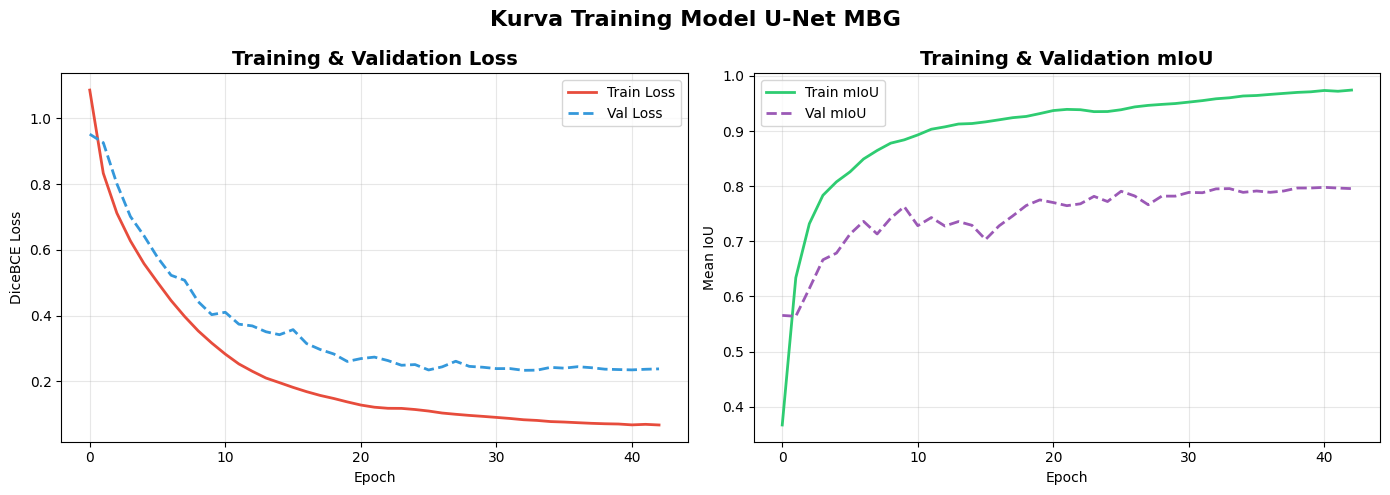

Plot tersimpan: training_history.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='#E74C3C', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   color='#3498DB', linewidth=2, linestyle='--')
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('DiceBCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_miou'], label='Train mIoU', color='#2ECC71', linewidth=2)
axes[1].plot(history['val_miou'],   label='Val mIoU',   color='#9B59B6', linewidth=2, linestyle='--')
axes[1].set_title('Training & Validation mIoU', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Mean IoU')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Kurva Training Model U-Net MBG', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot tersimpan: training_history.png')


In [ ]:
# Launch TensorBoard (jalankan di Colab)
# %load_ext tensorboard
# %tensorboard --logdir {LOG_DIR}


## Simpan & Load Model

In [17]:
# Simpan model final
FINAL_MODEL_PATH = 'models/unet_mbg_final.keras'
model.save(FINAL_MODEL_PATH)
print(f'Model final .keras tersimpan: {FINAL_MODEL_PATH}')

SAVED_MODEL_PATH = 'models/unet_mbg_savedmodel'
model.export(SAVED_MODEL_PATH)
print(f'SavedModel tersimpan       : {SAVED_MODEL_PATH}')

# Verifikasi load ulang
print('\nMemverifikasi load model...')
loaded_model = keras.models.load_model(
    FINAL_MODEL_PATH,
    custom_objects={
        'DiceBCELoss'  : DiceBCELoss,
        'AttentionGate': AttentionGate,
        'ConvBnRelu'   : ConvBnRelu,
        'MeanIoU'      : MeanIoU
    }
)
print(f'Output shape: {loaded_model.output_shape}')


Model final .keras tersimpan: models/unet_mbg_final.keras
Saved artifact at 'models/unet_mbg_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='input_image')
Output Type:
  TensorSpec(shape=(None, 256, 256, 6), dtype=tf.float32, name=None)
Captures:
  136208139729616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136207723479696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136207723479888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136208139719632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136208139730000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136208139729808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136207723481232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136207723482000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136207723481616: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1362077

`build()` was called on layer 'bridge_conv1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
`build()` was called on layer 'bridge_conv2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
`build()` was called on layer 'dec1_attn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
`build()` was called on layer 'dec1_c

Output shape: (None, 256, 256, 6)


## Evaluasi Model

In [19]:
def evaluate_model(model, dataset, class_mapping=CLASS_MAPPING,
                   num_classes=NUM_CLASSES):
    """Evaluasi loss, mIoU, dan per-class IoU pada dataset."""
    iou_per_class = np.zeros(num_classes)
    total_loss    = []
    count_per_cls = np.zeros(num_classes)

    for x_batch, y_batch in dataset:
        y_pred   = model(x_batch, training=False)
        loss     = loss_fn(y_batch, y_pred)
        total_loss.append(float(loss))
        pred_cls = tf.argmax(y_pred,  axis=-1).numpy()
        true_cls = tf.argmax(y_batch, axis=-1).numpy()

        for c in range(num_classes):
            inter = np.sum((pred_cls == c) & (true_cls == c))
            union = np.sum((pred_cls == c) | (true_cls == c))
            if union > 0:
                iou_per_class[c] += inter / union
                count_per_cls[c] += 1

    iou_per_class = np.where(count_per_cls > 0,
                             iou_per_class / count_per_cls, 0)
    mean_iou = np.mean(iou_per_class[1:])   # skip background

    print('='*55)
    print('Hasil Evaluasi Model')
    print(f'\nVal Loss (DiceBCE) : {np.mean(total_loss):.4f}')
    print(f'Mean IoU (non-bg)  : {mean_iou:.4f} ({mean_iou*100:.2f}%)')
    print('\n  Per-Class IoU:')
    for c, (name, iou) in enumerate(zip(class_mapping.values(), iou_per_class)):
        if c == 0: continue
        bar = '█' * int(iou * 25) + '░' * (25 - int(iou * 25))
        print(f'    {name:>12s} [{bar}] {iou*100:5.1f}%')
    print('='*55)
    return iou_per_class, mean_iou


# Evaluasi pada validation set
print("── Validation Set ──")
iou_per_class_val, mean_iou_val = evaluate_model(loaded_model, val_ds)

# Evaluasi pada test set
print("\n── Test Set ──")
iou_per_class_test, mean_iou_test = evaluate_model(loaded_model, test_ds)


── Validation Set ──
Hasil Evaluasi Model

Val Loss (DiceBCE) : 0.2379
Mean IoU (non-bg)  : 0.7713 (77.13%)

  Per-Class IoU:
            buah [█████████████████░░░░░░░░]  71.1%
     karbohidrat [█████████████████████░░░░]  85.4%
         protein [████████████████░░░░░░░░░]  64.8%
           sayur [██████████████████░░░░░░░]  74.6%
            susu [██████████████████████░░░]  89.7%

── Test Set ──
Hasil Evaluasi Model

Val Loss (DiceBCE) : 0.2184
Mean IoU (non-bg)  : 0.7839 (78.39%)

  Per-Class IoU:
            buah [███████████████████░░░░░░]  76.9%
     karbohidrat [█████████████████████░░░░]  87.6%
         protein [█████████████████░░░░░░░░]  68.2%
           sayur [█████████████████░░░░░░░░]  70.6%
            susu [██████████████████████░░░]  88.7%


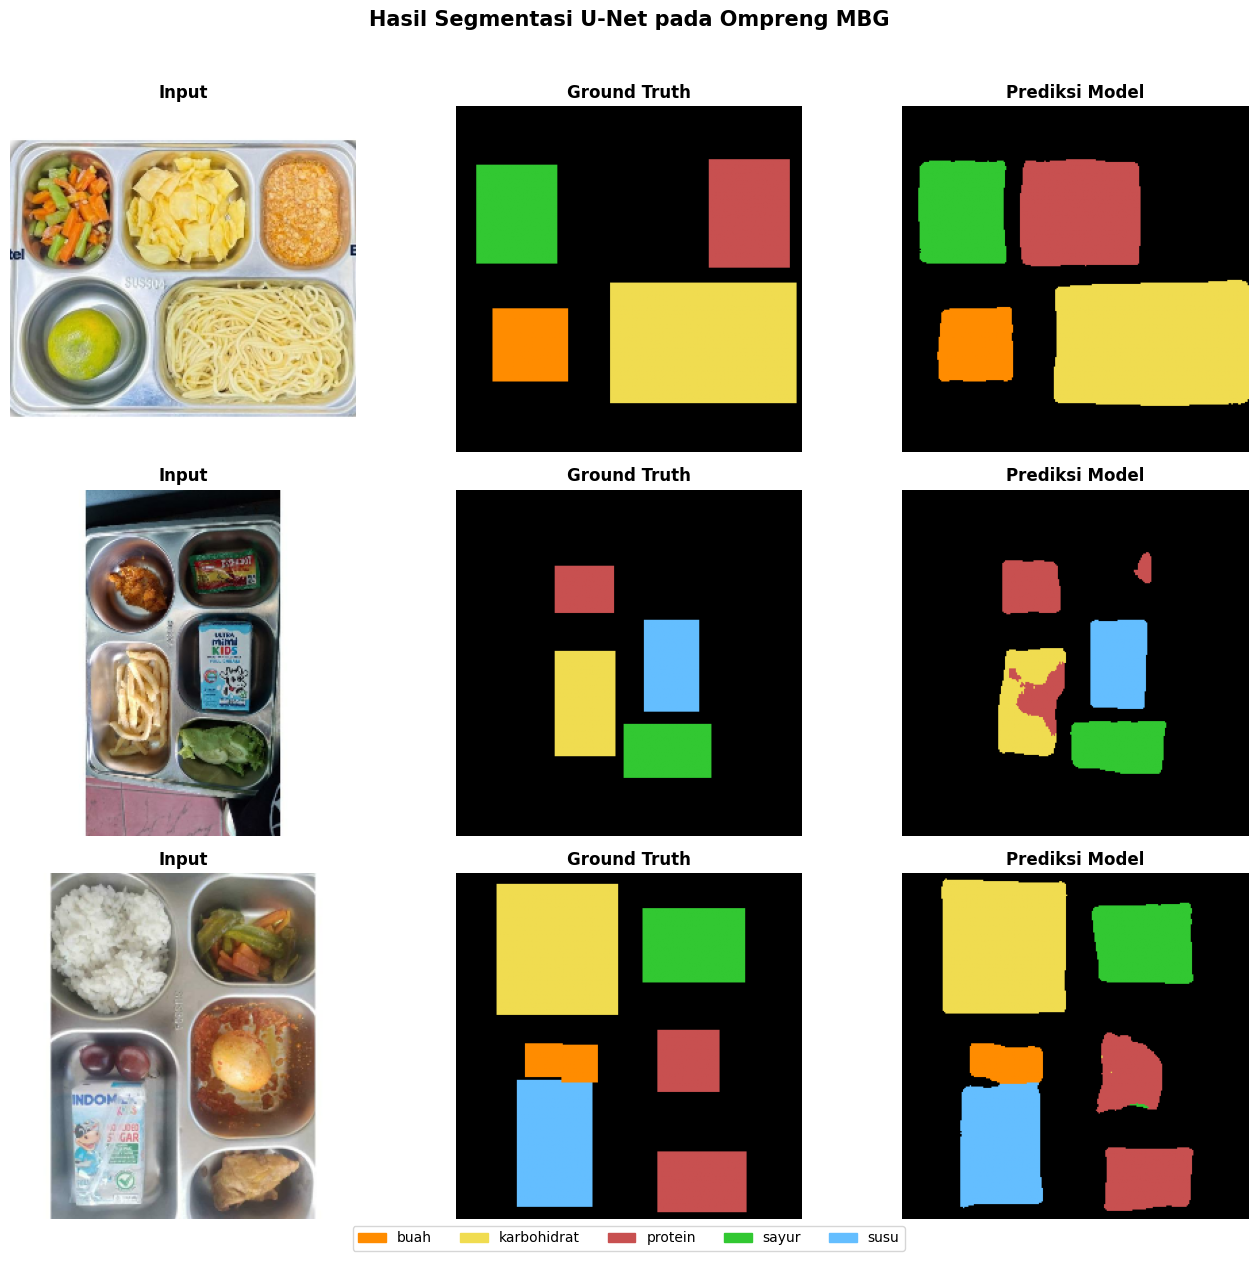

In [20]:
def visualize_predictions(model, dataset, class_mapping, class_colors, n=3):
    """Tampilkan input | ground truth | prediksi untuk n sampel."""
    fig, axes = plt.subplots(n, 3, figsize=(14, 4*n))
    if n == 1: axes = axes[np.newaxis, :]

    def to_color(mask):
        colored = np.zeros((*mask.shape, 3))
        for c, col in class_colors.items():
            colored[mask == c] = np.array(col) / 255.0
        return colored

    for i, (x_batch, y_batch) in enumerate(dataset.take(n)):
        img  = x_batch[0].numpy()
        true = tf.argmax(y_batch[0], axis=-1).numpy()
        pred = tf.argmax(model(x_batch[:1], training=False)[0], axis=-1).numpy()

        axes[i, 0].imshow(img);              axes[i, 0].set_title('Input',          fontweight='bold')
        axes[i, 1].imshow(to_color(true));   axes[i, 1].set_title('Ground Truth',   fontweight='bold')
        axes[i, 2].imshow(to_color(pred));   axes[i, 2].set_title('Prediksi Model', fontweight='bold')
        for ax in axes[i]: ax.axis('off')

    patches = [mpatches.Patch(color=np.array(c)/255, label=class_mapping[i])
               for i, c in class_colors.items() if i > 0]
    fig.legend(handles=patches, loc='lower center', ncol=len(patches),
               fontsize=10, bbox_to_anchor=(0.5, -0.02))

    plt.suptitle('Hasil Segmentasi U-Net pada Ompreng MBG',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('segmentation_results.png', dpi=150, bbox_inches='tight')
    plt.show()


visualize_predictions(loaded_model, val_ds, CLASS_MAPPING, CLASS_COLORS)


## Fuzzy Logic Classifier

In [21]:
def compute_nutrisi_proportion(pred_mask: np.ndarray,
                                class_mapping: dict,
                                nutrisi_mapping: dict) -> dict:
    """
    Hitung proporsi (%) tiap kategori nutrisi dari mask prediksi.
    Kelas 'ompreng' (tray) otomatis dilewati karena tidak ada di nutrisi_mapping.

    Kategori nutrisi: karbo | protein | serat | susu
    """
    pixel_per_class: dict = {}
    for cls_id, food_name in class_mapping.items():
        if cls_id == 0 or food_name not in nutrisi_mapping:
            continue   # skip background & ompreng
        pixel_count = np.sum(pred_mask == cls_id)
        if pixel_count > 0:
            pixel_per_class[food_name] = pixel_count

    total_food_pixels = sum(pixel_per_class.values())
    if total_food_pixels == 0:
        return {'karbo': 0.0, 'protein': 0.0, 'serat': 0.0, 'susu': 0.0}

    # Akumulasi piksel per kategori nutrisi
    nutrisi_pixels = {'karbo': 0, 'protein': 0, 'serat': 0, 'susu': 0}
    for food_name, pixels in pixel_per_class.items():
        nutrisi_cat = nutrisi_mapping[food_name]
        nutrisi_pixels[nutrisi_cat] += pixels

    # Proporsi (%)
    nutrisi_prop = {
        k: round(v / total_food_pixels * 100, 1)
        for k, v in nutrisi_pixels.items()
    }

    print('\n  Detail Piksel per Kelas Makanan:')
    for food, pix in pixel_per_class.items():
        nutr = nutrisi_mapping[food]
        pct  = pix / total_food_pixels * 100
        print(f'    {food:>12s} → {nutr:<8s}: {pix:>6d} piksel ({pct:5.1f}%)')
    print(f'    Total food pixels: {total_food_pixels}')

    return nutrisi_prop


In [22]:
class FuzzyNutritionClassifier:
    """
    Fuzzy Logic Classifier untuk status gizi ompreng MBG.
    Input  : proporsi karbo, protein, serat, susu (0-100 %)
    Output : status gizi + healthy score (0-100)

    Kategori status:
        seimbang | cukup_seimbang | kurang_seimbang |
        tidak_seimbang | sangat_tidak_seimbang
    """

    STATUS_LABELS = {
        (80, 101): 'seimbang',
        (60,  80): 'cukup_seimbang',
        (40,  60): 'kurang_seimbang',
        (20,  40): 'tidak_seimbang',
        (0,   20): 'sangat_tidak_seimbang'
    }

    def __init__(self):
        self._build_system()

    def _build_system(self):
        # Universe of discourse
        self.karbo   = ctrl.Antecedent(np.arange(0, 101, 1), 'karbo')
        self.protein = ctrl.Antecedent(np.arange(0, 101, 1), 'protein')
        self.serat   = ctrl.Antecedent(np.arange(0, 101, 1), 'serat')
        self.susu    = ctrl.Antecedent(np.arange(0, 101, 1), 'susu')
        self.score   = ctrl.Consequent(np.arange(0, 101, 1), 'score')

        # MF: Karbohidrat
        self.karbo['rendah'] = fuzz.trimf(self.karbo.universe, [0,   0,  40])
        self.karbo['sedang'] = fuzz.trimf(self.karbo.universe, [30,  50, 70])
        self.karbo['tinggi'] = fuzz.trimf(self.karbo.universe, [60, 100, 100])

        # MF: Protein
        self.protein['kurang'] = fuzz.trimf(self.protein.universe, [0,   0,  20])
        self.protein['cukup']  = fuzz.trimf(self.protein.universe, [15,  25, 35])
        self.protein['lebih']  = fuzz.trimf(self.protein.universe, [30, 100, 100])

        # MF: Serat (sayur + buah)
        self.serat['kurang'] = fuzz.trimf(self.serat.universe, [0,   0,  20])
        self.serat['cukup']  = fuzz.trimf(self.serat.universe, [15,  25, 40])
        self.serat['lebih']  = fuzz.trimf(self.serat.universe, [35, 100, 100])

        # MF: Susu — ada/tidak ada (khas MBG)
        self.susu['tidak_ada'] = fuzz.trimf(self.susu.universe, [0,   0,  5])
        self.susu['ada']       = fuzz.trimf(self.susu.universe, [3,  100, 100])

        # MF: Score output
        self.score['sangat_buruk'] = fuzz.trimf(self.score.universe, [0,   0,  20])
        self.score['buruk']        = fuzz.trimf(self.score.universe, [10,  25, 40])
        self.score['sedang']       = fuzz.trimf(self.score.universe, [30,  50, 70])
        self.score['baik']         = fuzz.trimf(self.score.universe, [60,  75, 90])
        self.score['sangat_baik']  = fuzz.trimf(self.score.universe, [80, 100, 100])

        # Fuzzy Rules
        rules = [
            # ── Komposisi ideal: karbo sedang + protein cukup + serat cukup + ada susu
            ctrl.Rule(self.karbo['sedang']  & self.protein['cukup'] &
                      self.serat['cukup']   & self.susu['ada'],
                      self.score['sangat_baik']),

            ctrl.Rule(self.karbo['sedang']  & self.protein['cukup'] &
                      self.serat['cukup']   & self.susu['tidak_ada'],
                      self.score['baik']),

            # ── Karbo berlebih
            ctrl.Rule(self.karbo['tinggi'],
                      self.score['buruk']),
            ctrl.Rule(self.karbo['tinggi']  & self.protein['kurang'],
                      self.score['sangat_buruk']),

            # ── Protein kurang
            ctrl.Rule(self.protein['kurang'],
                      self.score['buruk']),
            ctrl.Rule(self.protein['kurang'] & self.serat['kurang'],
                      self.score['sangat_buruk']),

            # ── Serat kurang
            ctrl.Rule(self.serat['kurang'],
                      self.score['buruk']),

            # ── Tanpa susu (komponen wajib MBG)
            ctrl.Rule(self.susu['tidak_ada'] & self.karbo['sedang'] &
                      self.protein['cukup'],
                      self.score['sedang']),

            # ── Karbo rendah tetapi protein cukup
            ctrl.Rule(self.karbo['rendah']  & self.protein['cukup'],
                      self.score['sedang']),

            # ── Karbo sedang + protein cukup + serat kurang
            ctrl.Rule(self.karbo['sedang']  & self.protein['cukup'] &
                      self.serat['kurang'],
                      self.score['sedang']),
        ]

        self.ctrl_system = ctrl.ControlSystem(rules)
        self.simulation  = ctrl.ControlSystemSimulation(self.ctrl_system)

    def classify(self, nutrisi: dict) -> dict:
        """Klasifikasi status gizi dari dict proporsi nutrisi."""
        self.simulation.input['karbo']   = np.clip(nutrisi.get('karbo',   0), 0, 100)
        self.simulation.input['protein'] = np.clip(nutrisi.get('protein', 0), 0, 100)
        self.simulation.input['serat']   = np.clip(nutrisi.get('serat',   0), 0, 100)
        self.simulation.input['susu']    = np.clip(nutrisi.get('susu',    0), 0, 100)

        try:
            self.simulation.compute()
            healthy_score = round(self.simulation.output['score'], 1)
        except Exception:
            healthy_score = 50.0

        status = 'tidak_seimbang'
        for (low, high), lbl in self.STATUS_LABELS.items():
            if low <= healthy_score < high:
                status = lbl
                break

        detail = self._rule_based_detail(nutrisi)

        return {
            'healthy_score': healthy_score,
            'status'       : status,
            'detail'       : detail,
            'nutrisi'      : nutrisi
        }

    def _rule_based_detail(self, nutrisi: dict) -> str:
        """Label detail berdasarkan heuristik proporsi nutrisi."""
        k = nutrisi.get('karbo',   0)
        p = nutrisi.get('protein', 0)
        s = nutrisi.get('serat',   0)
        u = nutrisi.get('susu',    0)

        if k > 60:
            return 'tinggi_karbo'
        if p < 15:
            if s < 15:
                return 'protein_dan_serat_kurang'
            return 'protein_kurang'
        if s < 15:
            return 'serat_kurang'
        if u == 0:
            return 'tanpa_susu'
        if 35 <= k <= 65 and p >= 15 and s >= 15 and u > 0:
            return 'seimbang'
        return 'cukup_seimbang'


# Inisialisasi
fuzzy_clf = FuzzyNutritionClassifier()

# Unit Test
test_cases = [
    {'karbo': 60, 'protein': 20, 'serat': 20, 'susu':  0},  # tinggi karbo, tanpa susu
    {'karbo': 50, 'protein': 20, 'serat': 20, 'susu': 10},  # seimbang + susu
    {'karbo': 70, 'protein':  5, 'serat':  5, 'susu':  0},  # buruk
    {'karbo': 40, 'protein': 20, 'serat': 30, 'susu': 10},  # seimbang ideal
]

print('Unit Test Fuzzy Logic Classifier:')
print('='*60)
for tc in test_cases:
    res = fuzzy_clf.classify(tc)
    print(f"  Input  : {tc}")
    print(f"  Status : {res['status']}  |  Detail: {res['detail']}  |  Score: {res['healthy_score']}")
    print('-'*60)


Unit Test Fuzzy Logic Classifier:
  Input  : {'karbo': 60, 'protein': 20, 'serat': 20, 'susu': 0}
  Status : cukup_seimbang  |  Detail: tanpa_susu  |  Score: 60.5
------------------------------------------------------------
  Input  : {'karbo': 50, 'protein': 20, 'serat': 20, 'susu': 10}
  Status : seimbang  |  Detail: seimbang  |  Score: 90.4
------------------------------------------------------------
  Input  : {'karbo': 70, 'protein': 5, 'serat': 5, 'susu': 0}
  Status : sangat_tidak_seimbang  |  Detail: tinggi_karbo  |  Score: 18.0
------------------------------------------------------------
  Input  : {'karbo': 40, 'protein': 20, 'serat': 30, 'susu': 10}
  Status : seimbang  |  Detail: seimbang  |  Score: 90.4
------------------------------------------------------------


## Inference Pipeline Lengkap

In [23]:
class MBGNutritionAnalyzer:
    """
    Pipeline lengkap: gambar → segmentasi U-Net → proporsi nutrisi → fuzzy classification.
    Kategori nutrisi: karbo | protein | serat | susu
    """

    STATUS_EMOJI = {
        'seimbang'             : '🟢',
        'cukup_seimbang'       : '🟡',
        'kurang_seimbang'      : '🟠',
        'tidak_seimbang'       : '🔴',
        'sangat_tidak_seimbang': '❌'
    }

    # Warna pie chart per kategori nutrisi
    NUTRISI_COLOR_MAP = {
        'karbo'  : '#F39C12',   # oranye-kuning
        'protein': '#E74C3C',   # merah
        'serat'  : '#2ECC71',   # hijau
        'susu'   : '#3498DB',   # biru
    }

    # Proporsi ideal MBG (karbo, protein, serat, susu)
    IDEAL_PROPORSI = {'karbo': 50, 'protein': 25, 'serat': 15, 'susu': 10}

    def __init__(self, model, fuzzy_clf, class_mapping, nutrisi_mapping,
                 class_colors, img_size=(IMG_HEIGHT, IMG_WIDTH)):
        self.model           = model
        self.fuzzy_clf       = fuzzy_clf
        self.class_mapping   = class_mapping
        self.nutrisi_mapping = nutrisi_mapping
        self.class_colors    = class_colors
        self.img_size        = img_size

    def preprocess(self, image_path: str) -> np.ndarray:
        img = cv2.imread(str(image_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, self.img_size)
        img = img.astype(np.float32) / 255.0
        return img[np.newaxis, ...]   # (1, H, W, C)

    def segment(self, img_tensor: np.ndarray) -> np.ndarray:
        pred = self.model(img_tensor, training=False)
        return tf.argmax(pred[0], axis=-1).numpy()   # (H, W)

    def mask_to_colored(self, mask: np.ndarray) -> np.ndarray:
        colored = np.zeros((*mask.shape, 3), dtype=np.uint8)
        for cls_id, color in self.class_colors.items():
            colored[mask == cls_id] = color
        return colored

    def analyze(self, image_path: str) -> dict:
        img_tensor   = self.preprocess(image_path)
        pred_mask    = self.segment(img_tensor)

        print('\nMenghitung proporsi nutrisi...')
        nutrisi_prop = compute_nutrisi_proportion(
            pred_mask, self.class_mapping, self.nutrisi_mapping
        )
        classification = self.fuzzy_clf.classify(nutrisi_prop)

        return {
            'image_path'    : image_path,
            'img_input'     : (img_tensor[0] * 255).astype(np.uint8),
            'pred_mask'     : pred_mask,
            'colored_mask'  : self.mask_to_colored(pred_mask),
            'nutrisi_prop'  : nutrisi_prop,
            'classification': classification
        }

    def visualize(self, result: dict, save_path: str = None):
        clf    = result['classification']
        nutr   = result['nutrisi_prop']
        score  = clf['healthy_score']
        status = clf['status']
        detail = clf['detail']
        emoji  = self.STATUS_EMOJI.get(status, '⚪')

        fig = plt.figure(figsize=(16, 10))
        fig.patch.set_facecolor('#F8F9FA')
        gs  = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

        # Panel 1: Gambar Input
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.imshow(result['img_input'])
        ax1.set_title('Foto Ompreng', fontweight='bold', fontsize=12)
        ax1.axis('off')

        # Panel 2: Mask Segmentasi
        ax2 = fig.add_subplot(gs[0, 1])
        ax2.imshow(result['colored_mask'])
        patches = [mpatches.Patch(color=np.array(c)/255, label=self.class_mapping[i])
                   for i, c in self.class_colors.items() if i > 0]
        ax2.legend(handles=patches, loc='lower right', fontsize=7)
        ax2.set_title('Segmentasi Makanan', fontweight='bold', fontsize=12)
        ax2.axis('off')

        # Panel 3: Pie Chart Proporsi Nutrisi
        ax3     = fig.add_subplot(gs[0, 2])
        labels  = [k for k, v in nutr.items() if v > 0]
        sizes   = [v for v in nutr.values()   if v > 0]
        pie_colors = [self.NUTRISI_COLOR_MAP.get(l, '#95A5A6') for l in labels]
        if sizes:
            wedges, texts, autotexts = ax3.pie(
                sizes, labels=labels, colors=pie_colors,
                autopct='%1.1f%%', startangle=90,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2}
            )
            for at in autotexts:
                at.set_fontsize(10); at.set_fontweight('bold')
        else:
            ax3.text(0.5, 0.5, 'Tidak ada\nmakanan terdeteksi',
                     ha='center', va='center', transform=ax3.transAxes)
        ax3.set_title('Proporsi Nutrisi', fontweight='bold', fontsize=12)

        # Panel 4: Healthy Score Gauge
        ax4 = fig.add_subplot(gs[1, 0])
        self._draw_gauge(ax4, score)

        # Panel 5: Aktual vs Target Nutrisi
        ax5 = fig.add_subplot(gs[1, 1])
        nutrisi_names  = list(nutr.keys())
        nutrisi_values = list(nutr.values())
        ideal_values   = [self.IDEAL_PROPORSI.get(n, 0) for n in nutrisi_names]
        x = np.arange(len(nutrisi_names))
        w = 0.35
        bars1 = ax5.bar(x - w/2, nutrisi_values, w, label='Aktual',
                        color=[self.NUTRISI_COLOR_MAP.get(n, '#95A5A6') for n in nutrisi_names],
                        alpha=0.85, edgecolor='white')
        bars2 = ax5.bar(x + w/2, ideal_values, w, label='Target Ideal',
                        color='#BDC3C7', alpha=0.7, edgecolor='white')
        ax5.bar_label(bars1, fmt='%.0f%%', fontsize=9, fontweight='bold')
        ax5.set_xticks(x); ax5.set_xticklabels(nutrisi_names, fontsize=10)
        ax5.set_ylabel('Proporsi (%)'); ax5.set_ylim(0, 100)
        ax5.set_title('Aktual vs Target Nutrisi', fontweight='bold', fontsize=12)
        ax5.legend(fontsize=9); ax5.grid(axis='y', alpha=0.3)

        # Panel 6: Status Card
        ax6 = fig.add_subplot(gs[1, 2])
        ax6.axis('off')
        status_color = {
            'seimbang'             : '#2ECC71',
            'cukup_seimbang'       : '#F1C40F',
            'kurang_seimbang'      : '#E67E22',
            'tidak_seimbang'       : '#E74C3C',
            'sangat_tidak_seimbang': '#C0392B'
        }.get(status, '#95A5A6')

        ax6.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax6.transAxes,
                                     color=status_color, alpha=0.15, clip_on=False))
        ax6.text(0.5, 0.85, f'{emoji} STATUS OMPRENG', ha='center', va='center',
                 transform=ax6.transAxes, fontsize=13, fontweight='bold')
        ax6.text(0.5, 0.65, status.upper().replace('_', ' '),
                 ha='center', va='center', transform=ax6.transAxes,
                 fontsize=16, fontweight='bold', color=status_color)
        ax6.text(0.5, 0.48, f'Detail: {detail.replace("_", " ")}',
                 ha='center', va='center', transform=ax6.transAxes,
                 fontsize=11, color='#555')
        ax6.text(0.5, 0.30, f'Healthy Score: {score:.0f}/100',
                 ha='center', va='center', transform=ax6.transAxes,
                 fontsize=14, fontweight='bold',
                 color='#27AE60' if score >= 70 else '#E74C3C')
        rec = self._get_recommendation(detail)
        ax6.text(0.5, 0.12, rec, ha='center', va='center',
                 transform=ax6.transAxes, fontsize=9, color='#333',
                 wrap=True, style='italic')

        plt.suptitle('Laporan Analisis Gizi Ompreng MBG',
                     fontsize=18, fontweight='bold', y=1.01)
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight',
                        facecolor=fig.get_facecolor())
            print(f'\nHasil tersimpan: {save_path}')
        plt.show()

    @staticmethod
    def _draw_gauge(ax, score: float):
        for t1, t2, c in [
            (np.pi,     np.pi*0.8, '#E74C3C'),
            (np.pi*0.8, np.pi*0.6, '#E67E22'),
            (np.pi*0.6, np.pi*0.4, '#F1C40F'),
            (np.pi*0.4, np.pi*0.2, '#2ECC71'),
            (np.pi*0.2, 0,         '#27AE60'),
        ]:
            thetas = np.linspace(t1, t2, 50)
            ax.plot(np.cos(thetas), np.sin(thetas), linewidth=15,
                    color=c, solid_capstyle='butt', alpha=0.8)

        angle = np.pi - (score / 100) * np.pi
        ax.annotate('', xy=(0.7*np.cos(angle), 0.7*np.sin(angle)),
                    xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', lw=3, color='#2C3E50'))
        ax.plot(0, 0, 'o', color='#2C3E50', markersize=12)
        ax.text(0, -0.35, f'{score:.0f}', ha='center', fontsize=22,
                fontweight='bold', color='#2C3E50')
        ax.text(0, -0.55, 'Healthy Score', ha='center', fontsize=10, color='#666')
        ax.set_xlim(-1.2, 1.2); ax.set_ylim(-0.7, 1.2)
        ax.set_aspect('equal'); ax.axis('off')
        ax.set_title('Healthy Score', fontweight='bold', fontsize=12)

    @staticmethod
    def _get_recommendation(detail: str) -> str:
        recs = {
            'seimbang'                 : 'Pertahankan komposisi gizi yang sudah baik ini!',
            'cukup_seimbang'           : 'Tambahkan sedikit lebih banyak sayur atau buah.',
            'tinggi_karbo'             : 'Kurangi porsi karbohidrat, perbanyak sayur & protein.',
            'protein_kurang'           : 'Tambahkan lauk protein (ayam/ikan/tempe/telur).',
            'serat_kurang'             : 'Perbanyak sayuran hijau dan buah-buahan.',
            'tanpa_susu'               : 'Lengkapi dengan susu sebagai sumber kalsium & protein.',
            'protein_dan_serat_kurang' : 'Tambahkan lauk protein dan porsi sayur/buah.',
        }
        return recs.get(detail, 'Konsultasikan dengan ahli gizi untuk saran lebih lanjut.')


## Jalankan Inference pada Gambar Test


Analisis Ompreng #1: mbg_1769505155_e1f8797e_jpg.rf.b516aa1b95e0638ea194365e33d68266.jpg

Menghitung proporsi nutrisi...

  Detail Piksel per Kelas Makanan:
            buah → serat   :   2145 piksel ( 11.0%)
     karbohidrat → karbo   :   5953 piksel ( 30.5%)
         protein → protein :   5834 piksel ( 29.9%)
           sayur → serat   :   5595 piksel ( 28.7%)
    Total food pixels: 19527

Proporsi Nutrisi:
         karbo:  30.5%
       protein:  29.9%
         serat:  39.6%
          susu:   0.0%

Hasil Klasifikasi:
  Status        : kurang_seimbang
  Detail        : tanpa_susu
  Healthy Score : 51.7/100


Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.



Hasil tersimpan: hasil_ompreng_1.png


Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.


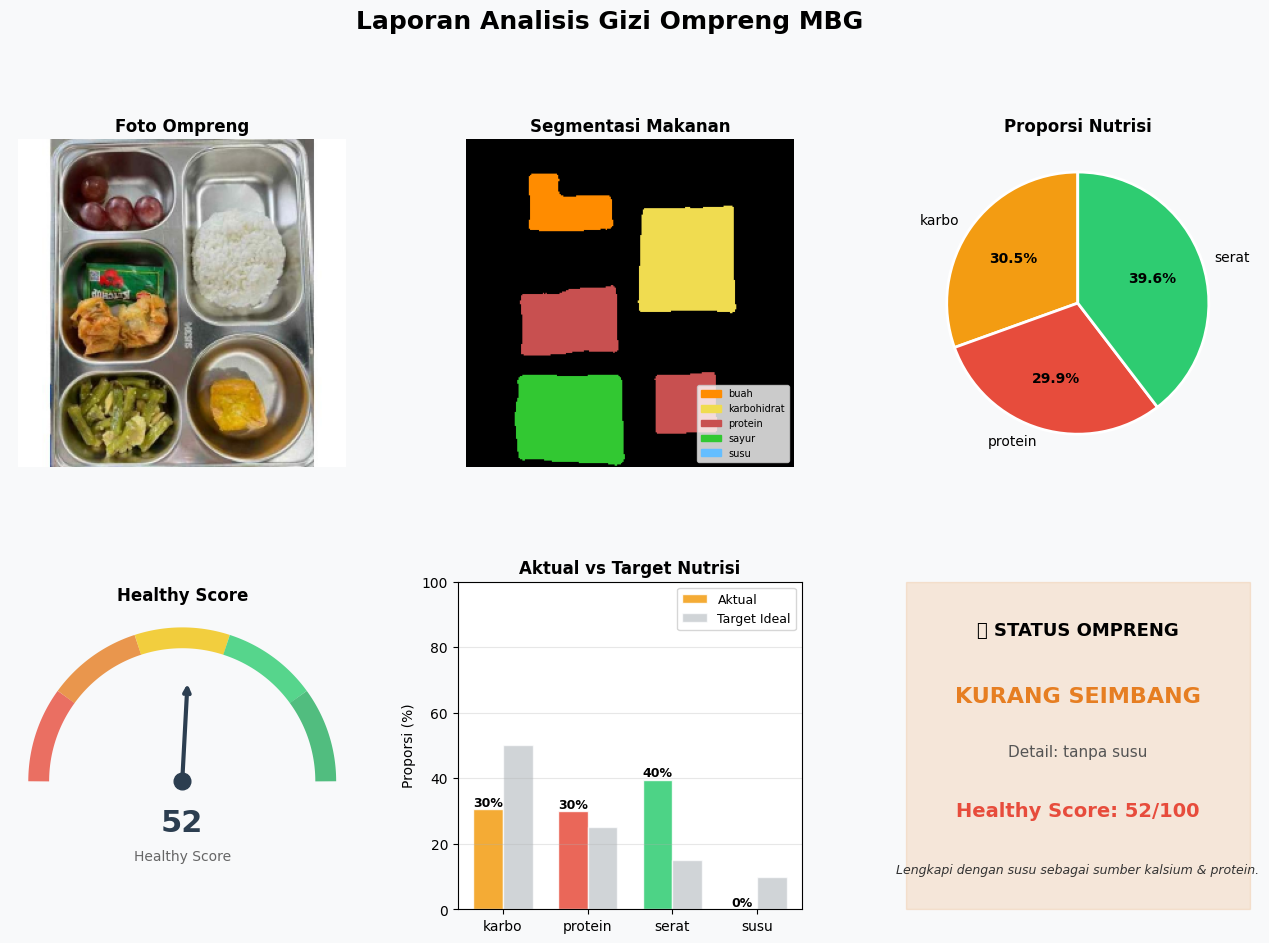


Analisis Ompreng #2: 50_581404891_17859297615544624_7591646092262914282_n_jpg.rf.c64dbf86fd8a82350ab8acd791dba660.jpg

Menghitung proporsi nutrisi...

  Detail Piksel per Kelas Makanan:
            buah → serat   :   3077 piksel ( 12.7%)
     karbohidrat → karbo   :   7487 piksel ( 31.0%)
         protein → protein :   8703 piksel ( 36.0%)
           sayur → serat   :   4917 piksel ( 20.3%)
    Total food pixels: 24184

Proporsi Nutrisi:
         karbo:  31.0%
       protein:  36.0%
         serat:  33.1%
          susu:   0.0%

Hasil Klasifikasi:
  Status        : kurang_seimbang
  Detail        : tanpa_susu
  Healthy Score : 50.0/100


Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.



Hasil tersimpan: hasil_ompreng_2.png


Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.


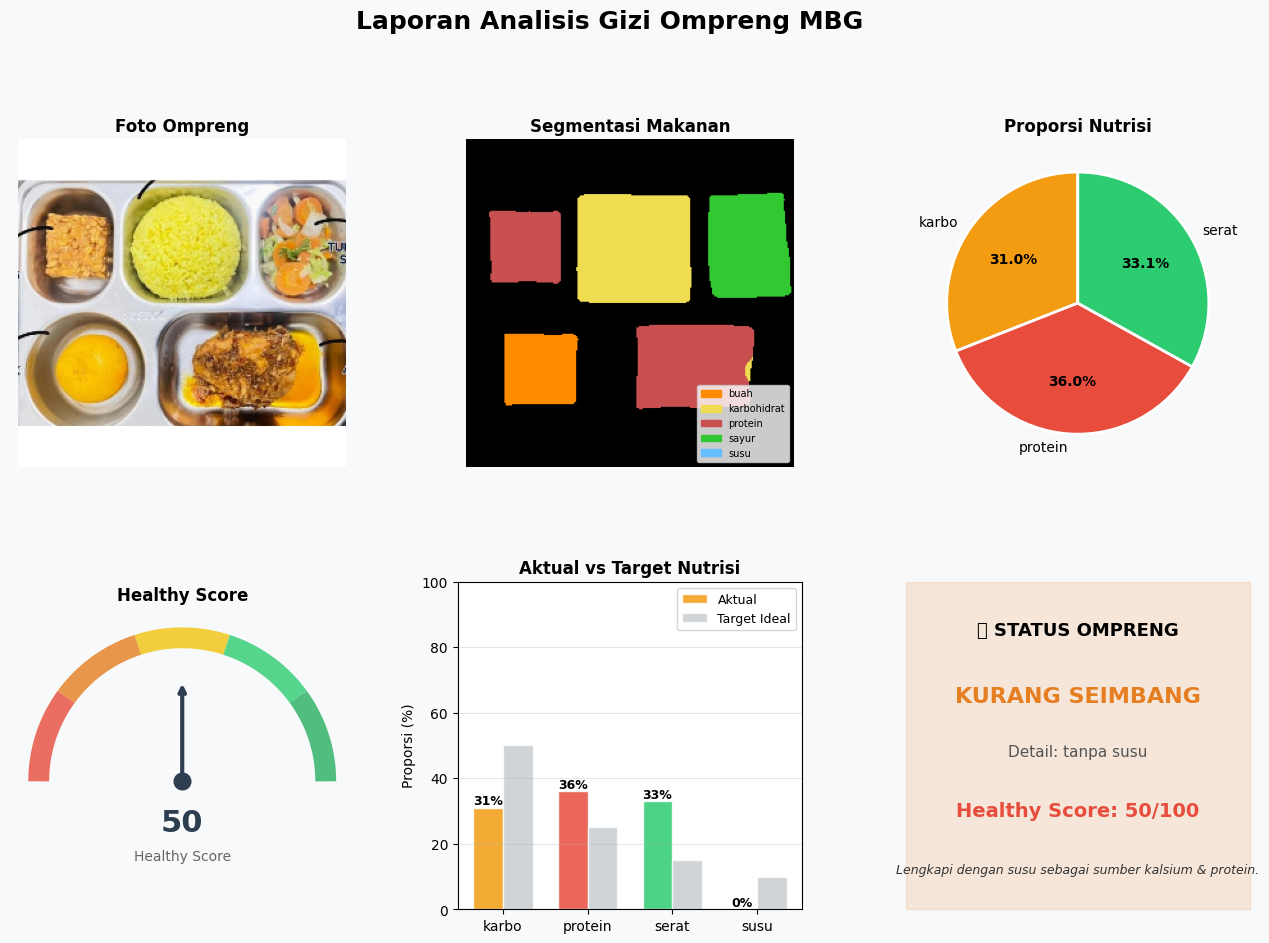


Analisis Ompreng #3: 42_590420604_17862303636549537_3287437404451747157_n_jpg.rf.a98572f59bf3b1b548e5a56c40c8a4c1.jpg

Menghitung proporsi nutrisi...

  Detail Piksel per Kelas Makanan:
            buah → serat   :   2445 piksel ( 10.8%)
     karbohidrat → karbo   :    197 piksel (  0.9%)
         protein → protein :   5814 piksel ( 25.7%)
           sayur → serat   :  14124 piksel ( 62.6%)
    Total food pixels: 22580

Proporsi Nutrisi:
         karbo:   0.9%
       protein:  25.7%
         serat:  73.4%
          susu:   0.0%

Hasil Klasifikasi:
  Status        : kurang_seimbang
  Detail        : tanpa_susu
  Healthy Score : 50.0/100


Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.



Hasil tersimpan: hasil_ompreng_3.png


Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.


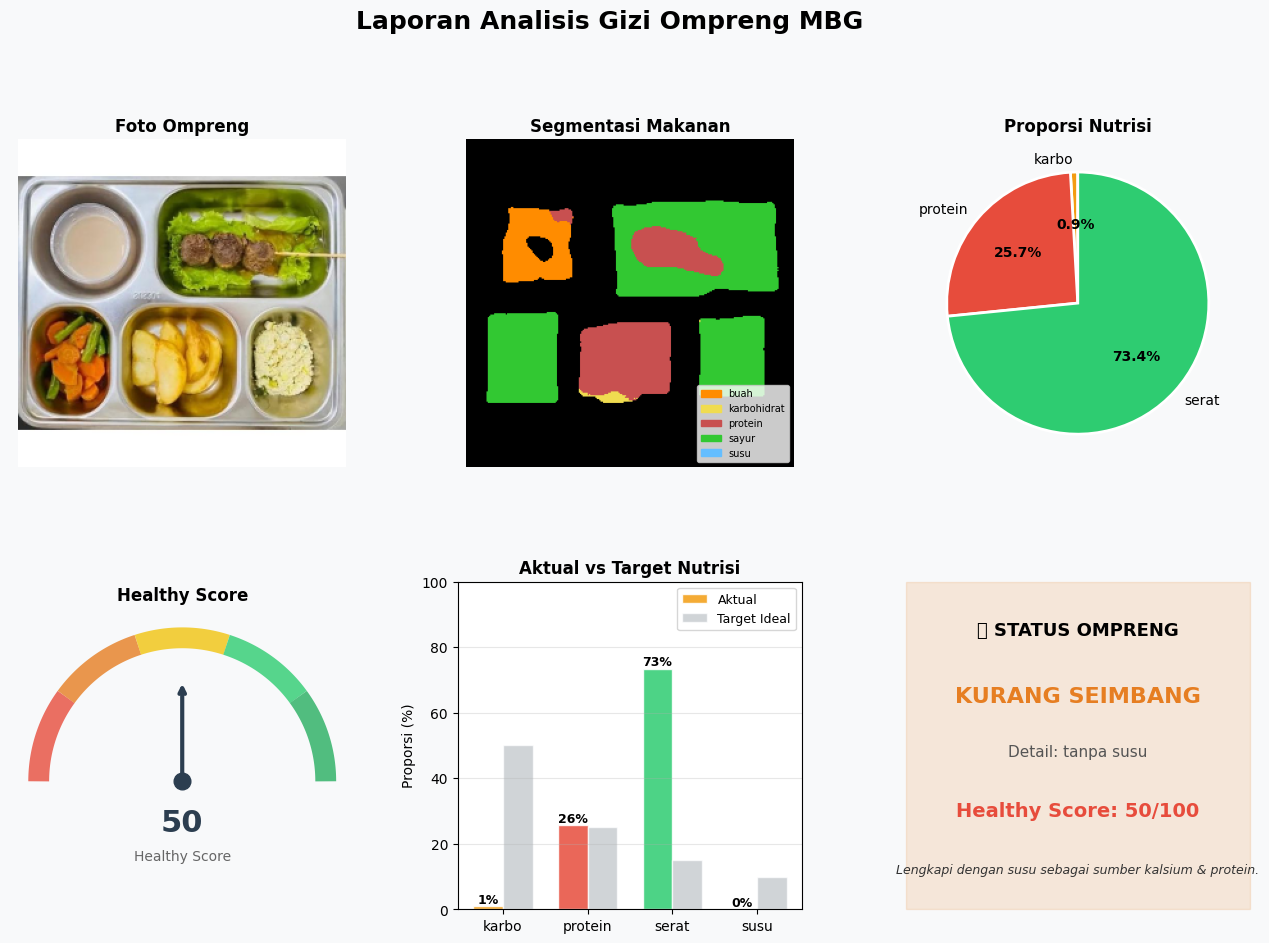

In [25]:
# Inisialisasi analyzer
analyzer = MBGNutritionAnalyzer(
    model          = loaded_model,
    fuzzy_clf      = fuzzy_clf,
    class_mapping  = CLASS_MAPPING,
    nutrisi_mapping= NUTRISI_MAPPING,
    class_colors   = CLASS_COLORS
)

# Pilih beberapa gambar dari test set
test_images = list(IMAGES_TEST.glob('*.[jp][pn]g'))[:3]
if not test_images:
    # Fallback ke train jika test kosong
    test_images = random.sample(list(IMAGES_TRAIN.glob('*.[jp][pn]g')), 3)

for i, img_path in enumerate(test_images):
    print(f"\n{'='*65}")
    print(f'Analisis Ompreng #{i+1}: {img_path.name}')
    print('='*65)

    result = analyzer.analyze(str(img_path))
    clf    = result['classification']

    print('\nProporsi Nutrisi:')
    for nutr, pct in result['nutrisi_prop'].items():
        print(f'    {nutr:>10s}: {pct:5.1f}%')

    print('\nHasil Klasifikasi:')
    print(f'  Status        : {clf["status"]}')
    print(f'  Detail        : {clf["detail"]}')
    print(f'  Healthy Score : {clf["healthy_score"]}/100')

    analyzer.visualize(result, save_path=f'hasil_ompreng_{i+1}.png')

## Demo Inference dari Custom Input

In [26]:
def predict_ompreng(image_path: str,
                    model_path: str = FINAL_MODEL_PATH,
                    return_json: bool = False) -> dict:
    """
    Fungsi inference siap produksi untuk satu gambar ompreng.

    Args:
        image_path  : path gambar (jpg/png)
        model_path  : path file .keras
        return_json : True → kembalikan dict JSON-serializable

    Returns:
        dict hasil analisis lengkap
    """
    seg_model = keras.models.load_model(
        model_path,
        custom_objects={
            'DiceBCELoss'  : DiceBCELoss,
            'AttentionGate': AttentionGate,
            'ConvBnRelu'   : ConvBnRelu,
            'MeanIoU'      : MeanIoU
        }
    )
    fz_clf = FuzzyNutritionClassifier()
    anlzr  = MBGNutritionAnalyzer(
        model          = seg_model,
        fuzzy_clf      = fz_clf,
        class_mapping  = CLASS_MAPPING,
        nutrisi_mapping= NUTRISI_MAPPING,
        class_colors   = CLASS_COLORS
    )

    result = anlzr.analyze(image_path)

    if return_json:
        return {
            'image_path'   : image_path,
            'nutrisi_prop' : result['nutrisi_prop'],
            'status'       : result['classification']['status'],
            'detail'       : result['classification']['detail'],
            'healthy_score': result['classification']['healthy_score'],
            'rekomendasi'  : MBGNutritionAnalyzer._get_recommendation(
                                result['classification']['detail'])
        }

    anlzr.visualize(result)
    return result


# Contoh penggunaan
sample_img  = str(test_images[0])
json_result = predict_ompreng(sample_img, return_json=True)

print('\nOutput JSON Inference:')
print(json.dumps(json_result, indent=2, ensure_ascii=False))


`build()` was called on layer 'bridge_conv1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
`build()` was called on layer 'bridge_conv2', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
`build()` was called on layer 'dec1_attn', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
`build()` was called on layer 'dec1_c


Menghitung proporsi nutrisi...

  Detail Piksel per Kelas Makanan:
            buah → serat   :   2145 piksel ( 11.0%)
     karbohidrat → karbo   :   5953 piksel ( 30.5%)
         protein → protein :   5834 piksel ( 29.9%)
           sayur → serat   :   5595 piksel ( 28.7%)
    Total food pixels: 19527

Output JSON Inference:
{
  "image_path": "Ompreng-MBG-Fix-2/test/mbg_1769505155_e1f8797e_jpg.rf.b516aa1b95e0638ea194365e33d68266.jpg",
  "nutrisi_prop": {
    "karbo": 30.5,
    "protein": 29.9,
    "serat": 39.6,
    "susu": 0.0
  },
  "status": "kurang_seimbang",
  "detail": "tanpa_susu",
  "healthy_score": 51.7,
  "rekomendasi": "Lengkapi dengan susu sebagai sumber kalsium & protein."
}
